In [7]:
from hydra import compose, initialize
from omegaconf import OmegaConf
import json
import os
from pathlib import Path
import glob
with initialize(config_path="dev/patch_icl/configs"):
    cfg = compose(config_name="config")

print(OmegaConf.to_yaml(cfg.paths))

totalseg: /nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/data/totalseg
nnunet: /nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/results/nnunet
results: results
checkpoints: results/checkpoints



/tmp/ipykernel_104/3571869983.py:7: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path="dev/patch_icl/configs"):


In [8]:
print(f"export nnUNet_raw=\"{cfg.paths.nnunet}/nnUNet_raw\"")
print(f"export nnUNet_preprocessed=\"{cfg.paths.nnunet}/nnUNet_preprocessed\"")
print(f"export nnUNet_results=\"{cfg.paths.nnunet}/nnUNet_results\"")

# exectute the above commands in the terminal to set the nnUNet environment variables : 
import subprocess
subprocess.run(f"export nnUNet_raw=\"{cfg.paths.nnunet}/nnUNet_raw\"", shell=True, check=True)
subprocess.run(f"export nnUNet_preprocessed=\"{cfg.paths.nnunet}/nnUNet_preprocessed\"", shell=True, check=True)
subprocess.run(f"export nnUNet_results=\"{cfg.paths.nnunet}/nnUNet_results\"", shell=True, check=True)

export nnUNet_raw="/nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/results/nnunet/nnUNet_raw"
export nnUNet_preprocessed="/nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/results/nnunet/nnUNet_preprocessed"
export nnUNet_results="/nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/results/nnunet/nnUNet_results"


CompletedProcess(args='export nnUNet_results="/nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/results/nnunet/nnUNet_results"', returncode=0)

In [14]:
subprocess.run("pwd")

/home/dpxuser


CompletedProcess(args='pwd', returncode=0)

In [19]:
ALL_CLASSES: list[str] = [
    "adrenal_gland_left", "adrenal_gland_right", "aorta", "atrial_appendage_left",
    "autochthon_left", "autochthon_right", "brachiocephalic_trunk",
    "brachiocephalic_vein_left", "brachiocephalic_vein_right", "brain",
    "clavicula_left", "clavicula_right", "colon", "common_carotid_artery_left",
    "common_carotid_artery_right", "costal_cartilages", "duodenum", "esophagus",
    "femur_left", "femur_right", "gallbladder", "gluteus_maximus_left",
    "gluteus_maximus_right", "gluteus_medius_left", "gluteus_medius_right",
    "gluteus_minimus_left", "gluteus_minimus_right", "heart", "hip_left", "hip_right",
    "humerus_left", "humerus_right", "iliac_artery_left", "iliac_artery_right",
    "iliac_vena_left", "iliac_vena_right", "iliopsoas_left", "iliopsoas_right",
    "inferior_vena_cava", "kidney_cyst_left", "kidney_cyst_right",
    "kidney_left", "kidney_right", "liver",
    "lung_lower_lobe_left", "lung_lower_lobe_right", "lung_middle_lobe_right",
    "lung_upper_lobe_left", "lung_upper_lobe_right",
    "pancreas", "portal_vein_and_splenic_vein", "prostate", "pulmonary_vein",
    "rib_left_1", "rib_left_2", "rib_left_3", "rib_left_4", "rib_left_5",
    "rib_left_6", "rib_left_7", "rib_left_8", "rib_left_9", "rib_left_10",
    "rib_left_11", "rib_left_12",
    "rib_right_1", "rib_right_2", "rib_right_3", "rib_right_4", "rib_right_5",
    "rib_right_6", "rib_right_7", "rib_right_8", "rib_right_9", "rib_right_10",
    "rib_right_11", "rib_right_12",
    "sacrum", "scapula_left", "scapula_right", "skull", "small_bowel",
    "spinal_cord", "spleen", "sternum", "stomach",
    "subclavian_artery_left", "subclavian_artery_right", "superior_vena_cava",
    "thyroid_gland", "trachea", "urinary_bladder",
    "vertebrae_C1", "vertebrae_C2", "vertebrae_C3", "vertebrae_C4",
    "vertebrae_C5", "vertebrae_C6", "vertebrae_C7",
    "vertebrae_L1", "vertebrae_L2", "vertebrae_L3", "vertebrae_L4", "vertebrae_L5",
    "vertebrae_S1",
    "vertebrae_T1", "vertebrae_T2", "vertebrae_T3", "vertebrae_T4", "vertebrae_T5",
    "vertebrae_T6", "vertebrae_T7", "vertebrae_T8", "vertebrae_T9",
    "vertebrae_T10", "vertebrae_T11", "vertebrae_T12",
]
_ALL_CLASSES_IDX: dict[str, int] = {cls: i + 1 for i, cls in enumerate(ALL_CLASSES)}



In [20]:
import sys, shutil, json
from multiprocessing import Pool
import nibabel as nib
import numpy as np
from tqdm.auto import tqdm



pretrain_classes = list(cfg.data.pretrain_classes)
# orig label value (1-based ALL_CLASSES index) → new contiguous index (1-based)
orig_to_new = {
    _ALL_CLASSES_IDX[cls]: new_idx
    for new_idx, cls in enumerate(pretrain_classes, start=1)
    if cls in _ALL_CLASSES_IDX
}

dataset_id   = "001"
dataset_name = "TotalSeg"
dataset_dir  = Path(cfg.paths.nnunet) / "nnUNet_raw" / f"Dataset{dataset_id}_{dataset_name}"
images_dir   = dataset_dir / "imagesTr"
labels_dir   = dataset_dir / "labelsTr"
images_dir.mkdir(parents=True, exist_ok=True)
labels_dir.mkdir(parents=True, exist_ok=True)

subjects = sorted([p.name for p in Path(cfg.paths.totalseg).iterdir() if p.is_dir()])


def _process(args):
    sid, totalseg_root, images_dir, labels_dir, orig_to_new = args
    src      = Path(totalseg_root) / sid
    ct_path  = src / "ct.nii.gz"
    lbl_path = src / "label.npy"
    if not ct_path.exists() or not lbl_path.exists():
        return False

    shutil.copy(ct_path, Path(images_dir) / f"{sid}_0000.nii.gz")

    raw = np.load(lbl_path)          # uint8, 1-based ALL_CLASSES indices
    out = np.zeros_like(raw)
    for orig, new in orig_to_new.items():
        out[raw == orig] = new
    ct_img = nib.load(str(ct_path))
    nib.save(nib.Nifti1Image(out, ct_img.affine, ct_img.header),
             Path(labels_dir) / f"{sid}.nii.gz")
    return True


task_args = [(sid, cfg.paths.totalseg, str(images_dir), str(labels_dir), orig_to_new)
             for sid in subjects]

with Pool(processes=8) as pool:
    results = list(tqdm(pool.imap(_process, task_args), total=len(task_args)))

n_ok = sum(results)

dataset_json = {
    "channel_names": {"0": "CT"},
    "labels": {"background": 0} | {cls: i for i, cls in enumerate(pretrain_classes, start=1)},
    "numTraining": n_ok,
    "file_ending": ".nii.gz",
}
with open(dataset_dir / "dataset.json", "w") as f:
    json.dump(dataset_json, f, indent=2)

print(f"Done: {n_ok}/{len(subjects)} cases, {len(pretrain_classes)} classes → {dataset_dir}")


  0%|          | 0/1228 [00:00<?, ?it/s]

Done: 1228/1228 cases, 30 classes → /nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/results/nnunet/nnUNet_raw/Dataset001_TotalSeg


nnUNetv2_plan_and_preprocess --n-workers 20 -d 1 --verify_dataset_integrity -c 3d_fullres -pl nnUNetPlannerResEncM -gpu_memory_target 40 -overwrite_plans_name nnUNetResEncUNetPlans_40G
nnUNetv2_train 1 3d_fullres -p nnUNetResEncUNetPlans_40G all

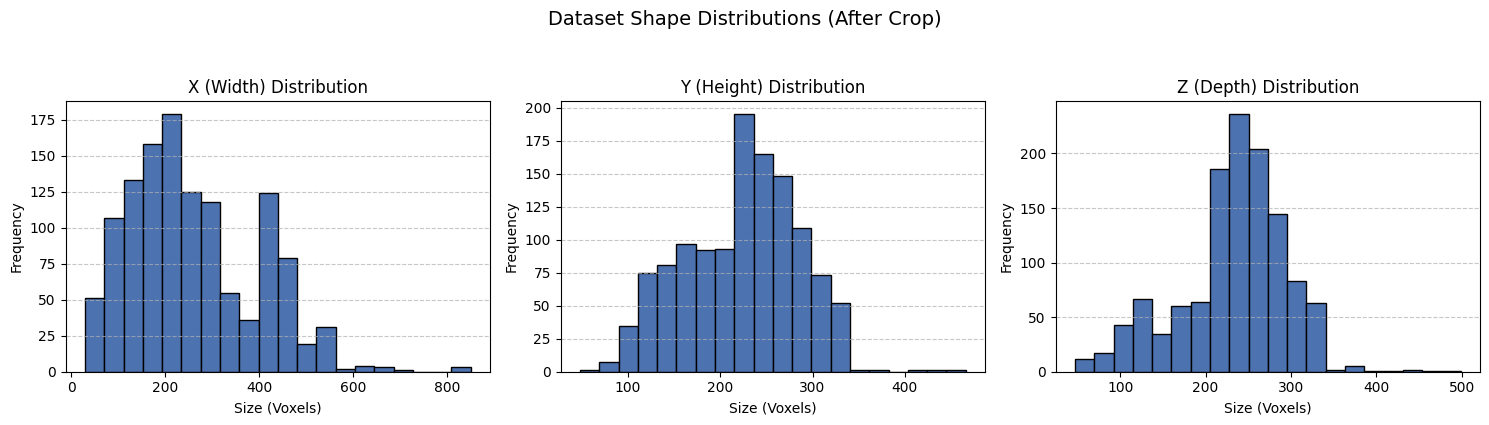

In [21]:
import json
import matplotlib.pyplot as plt

# 1. Point this to your actual dataset_fingerprint.json path
json_path = cfg.paths.nnunet + "/nnUNet_preprocessed/Dataset001_TotalSeg/dataset_fingerprint.json"

# Load the JSON data
with open(json_path, 'r') as f:
    data = json.load(f)

# Extract the list of shapes
shapes = data.get("shapes_after_crop", [])

if not shapes:
    print("No 'shapes_after_crop' found in the JSON file.")
else:
    # 2. Separate into X, Y, and Z lists
    # zip(*shapes) cleanly transposes the list of [[x,y,z], [x,y,z]] into ([x,x], [y,y], [z,z])
    axes_data = list(zip(*shapes))
    
    num_axes = len(axes_data)
    axis_labels = ['X (Width)', 'Y (Height)', 'Z (Depth)']
    
    # 3. Setup the plot
    fig, axes = plt.subplots(1, num_axes, figsize=(5 * num_axes, 4))
    
    # Handle the rare case of 2D data where subplots returns a flat array
    if num_axes == 1:
        axes = [axes]
        
    # Plot a histogram for each axis
    for i, (ax, ax_data) in enumerate(zip(axes, axes_data)):
        label = axis_labels[i] if i < len(axis_labels) else f"Dim {i}"
        
        ax.hist(ax_data, bins=20, color='#4C72B0', edgecolor='black')
        ax.set_title(f'{label} Distribution')
        ax.set_xlabel('Size (Voxels)')
        ax.set_ylabel('Frequency')
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.suptitle("Dataset Shape Distributions (After Crop)", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()